In [1]:
import dataclasses
import json

import colorcet
import einops
import h5py
import matplotlib.pyplot as plt
import numpy as np

from lib.plots import set_axis
from lib.stats import fit_power_law

In [43]:
task_id = "task-9"

with h5py.File(f"{task_id}/_outputs/metrics-nocen.h5", "r") as store:
    metrics = Metrics(
        config=json.loads(store["config"][()]),
        site_msds=store["site_msds"][:, :, :],
        separation_scores=store["separation_scores"][:],
        separation_histories=store["separation_histories"][:],
    )

In [44]:
chain_used, = metrics.config["chains"]
chain_length = chain_used["length"]
default_valency = metrics.config["association"]["valency"]

selector_a = np.full(chain_length, False)
for feature in chain_used.get("association_features", []):
    is_a = False
    match feature:
        case {"valency": valency}:
            is_a = (valency < default_valency)

        case {"association": _} | {"dissociation": _}:
            assoc = feature.get("association", 1)
            dissoc = feature.get("dissociation", 1)
            is_a = (assoc < dissoc)

    if is_a:
        site = feature["site"]
        start = site["start"]
        end = site["end"]
        selector_a[start:end] = True

selector_b = ~selector_a

phi  0.16049382716049382


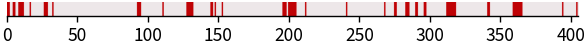

In [45]:
fig, ax = plt.subplots(figsize=(3.0, 0.3))

ax.matshow(
    selector_a[None, :],
    origin="lower",
    extent=[0, chain_length, 1, 0],
    aspect="auto",
    vmin=-1,
    vmax=1,
    cmap=colorcet.m_coolwarm,
    interpolation="kaiser",
)
set_axis(ax, "bottom")

print("phi ", selector_a.mean())

pass

In [46]:
msds = metrics.site_msds.mean(axis=2)
msds = msds[:, :11]
msds.shape

(20, 11)

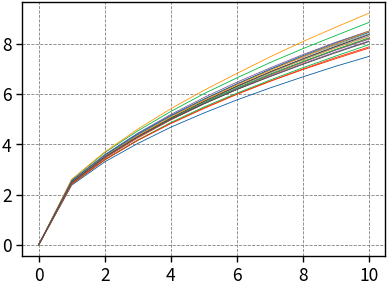

In [47]:
lags = np.arange(msds.shape[1])

fig, ax = plt.subplots()

for i, msd in enumerate(msds):
    x = lags
    y = msd
    ax.plot(x, y, lw=0.3)

ax.grid(True)

pass